# 1.1 Radial velocity analysis of WASP-12b 

### Universidad de La Laguna Exo & Exo 2024-2025 exercise 1

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 21.4.2025

This first exercise teaches you how to estimate the minimum planetary mass from radial velocity measurements using [Bayesian inference](https://en.wikipedia.org/wiki/Bayesian_inference).


## (The absolute basics of) radial velocities

A planet orbiting a star causes the star to [move around the star-planet barycentre](https://exoplanets.nasa.gov/alien-worlds/ways-to-find-a-planet/#/1). This leads to a periodic change in the star's position and velocity,
and the radial component of the star's velocity can be measured using [doppler spectroscopy](https://en.wikipedia.org/wiki/Doppler_spectroscopy). Radial velocity (RV) measurements are used to search for unknown planets and to estimate the minimum masses and orbital periods of known planets.

![Doppler shift vs time](Doppler_Shift_vs_Time.svg "Doppler shift vs time")


A planet with a mass $M_\mathrm{p}$ orbiting a star with a mass $M_\star$ with an orbital period $P$ leads to a periodic signal with a semi-amplitude of

$$
K = \left(\frac{2\pi G}{P}\right)^{1/3} \frac{M_\mathrm{p} \sin i}{(M_\star + M_\mathrm{p})^{2/3}} \frac{1}{(1-e^2)^{1/2}},
$$

where $G$ is the [gravitational constant](https://en.wikipedia.org/wiki/Gravitational_constant), $e$ is the [orbital eccentricity](https://en.wikipedia.org/wiki/Orbital_eccentricity), and $i$ is the [orbital inclination](https://en.wikipedia.org/wiki/Orbital_inclination). After we estimate $P$, $K$, and $M_\star$ we can solve for the minimum planetary mass $M_\mathrm{p} \sin i$. The orbital period and RV semi-amplitude can be estimated directly from the RV signal, but the stellar mass needs to be estimated using other means.


## (The absolute basics of) Bayesian parameter estimation

Measuring the RV semi-amplitude and the orbital period from RV measurements is a *parameter estimation* problem: we assume we have an adequate model to describe the observations, and we want to infer the model parameters with their uncertainties.

We take a [*Bayesian*](http://en.wikipedia.org/wiki/Bayesian_probability) approach to the parameter estimation, where we want to estimate the [*posterior probability*](http://en.wikipedia.org/wiki/Posterior_probability) for the model parameters given their [*prior probabilities*](http://en.wikipedia.org/wiki/Prior_probability) and a set of observations. The posterior probability density given a parameter vector $\theta$ and observational data $D$ is described by the [*Bayes' theorem*](http://en.wikipedia.org/wiki/Bayes%27_theorem) as

$$
P(\theta|D) = \frac{P(\theta) P(D|\theta)}{P(D)}, \qquad P(D|\theta) = \prod P(D_i|\theta),
$$

where $P(\theta)$ is the prior, $P(D|\theta)$ is the [*likelihood*](http://en.wikipedia.org/wiki/Likelihood_function) for the data, and $P(D)$ is a [*normalising factor*](http://en.wikipedia.org/wiki/Marginal_likelihood) we don't need to bother with during MCMC-based parameter estimation. 

The likelihood is a product of individual observation probabilities, and has the unfortunate tendency to end up being either very small or very big. This causes computational headaches, and it is better to work with log probabilities instead, so that

$$
\log P(\theta|D) = \log P(\theta) + \log P(D|\theta),  \qquad \log P(D|\theta) = \sum \log P(D_i|\theta)
$$

where we have omitted the $P(D)$ term from the posterior density.

Now we still need to decide our likelihood density. If we can assume normally distributed white noise--that is, the errors in the observations are independent and identically distributed--we end up with a log likelihood function

$$
 \log P(D|\theta) = -N\log(\sigma) -\frac{N\log 2\pi}{2} - \sum_{i=0}^N \frac{(o_i-m_i)^2}{2\sigma^2},
$$

where $N$ is the number of datapoints, $\sigma$ is the white noise standard deviation, $o$ is the observed data, and $m$ is the model. 

This should be enough for these exercies, but you can find more information from [A primer about Bayesian statistics](https://ui.adsabs.harvard.edu/link_gateway/2018haex.bookE.149P/EPRINT_PDF) and the references therein.

## Initialisation

In [1]:
%matplotlib inline

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, median
from astropy.table import Table
from astropy.timeseries import LombScargle
from corner import corner

from pytransit.lpf.rvlpf import RVLPF

rc('figure', figsize=(13,4))

## 1.1 Read in the RV data 

The radial velocity measurements consist of mid-observation times, radial velocity values, and radial velocity measurement uncertainties (also called as 'errors'). We use the data from [Yee et al. (2019)](https://iopscience.iop.org/article/10.3847/2041-8213/ab5c16). The data is stored as a CDS table that can be read directly using `astropy.table.Table`.

In [7]:
rv_data = Table.read('data/wasp_12b_yee_2019.dat', format='ascii.cds')

It's important to understand what sort of data we're dealing with, so we begin by displaying the table header and the five first rows.

In [8]:
rv_data[:5]  

BJD,RVel,e_RVel
d,m / s,m / s
float64,float64,float64
2455521.959432,-136.635,2.534
2455543.089922,5.728,2.919
2455545.983884,-162.39,2.822
2455559.906718,141.616,2.345
2455559.917563,115.818,2.727


It's also useful to visualise directly what we're working with, so we next plot the radial velocity data and its uncertainties as a function of time.

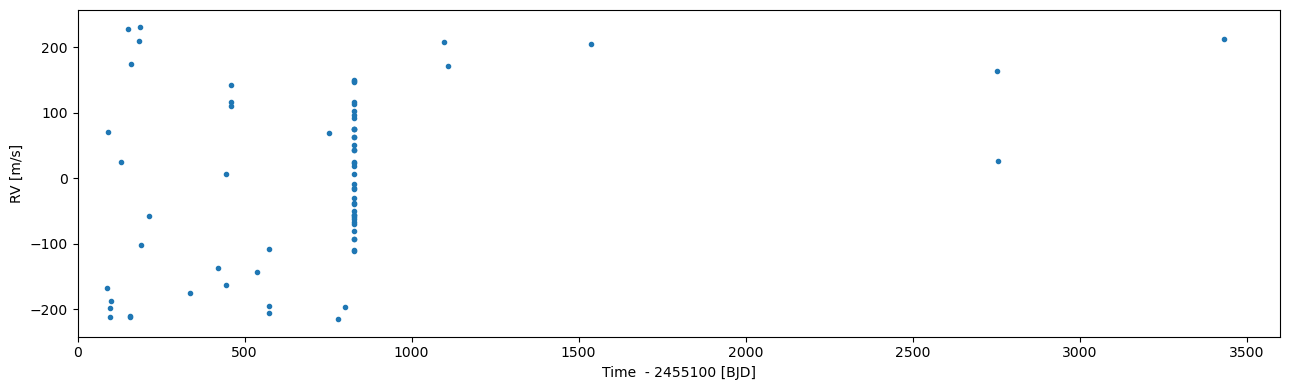

In [15]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] - 2455100, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Time  - 2455100 [BJD]', ylabel='RV [m/s]', xlim=(0, 3600))
fig.tight_layout()
plt.show()

### <span style="color:darkblue">Questions and exercises:</span>

1. Try to describe the logic behind the time sampling of the RV observations.

-The time sampling for radial velocity (RV) observations is designed to measure the star's periodic wobble caused by the planet. This wobble is a signal (like a sine wave) that repeats with the planet's orbital period.

The main goal of the sampling is to capture this periodic signal across the full orbit. This is done by taking observations at various times, spread out over the orbital period. Getting points at different orbital phases allows us to determine the signal's amplitude (related to the planet's mass) and precisely measure the orbital period.

Observations are often grouped into "visits" (e.g., on different nights) due to telescope scheduling. Multiple points might be taken within a visit to cover a specific phase range or help distinguish stellar activity from the planet's signal.

In short, the sampling strategy aims to map out the star's velocity changes over time to characterize the planet's gravitational pull, especially focusing on covering the full orbital cycle to measure the size and timing of the velocity wobble.

2. Plot below the RV observations as a function of time focusing on the densely-sampled time-span.

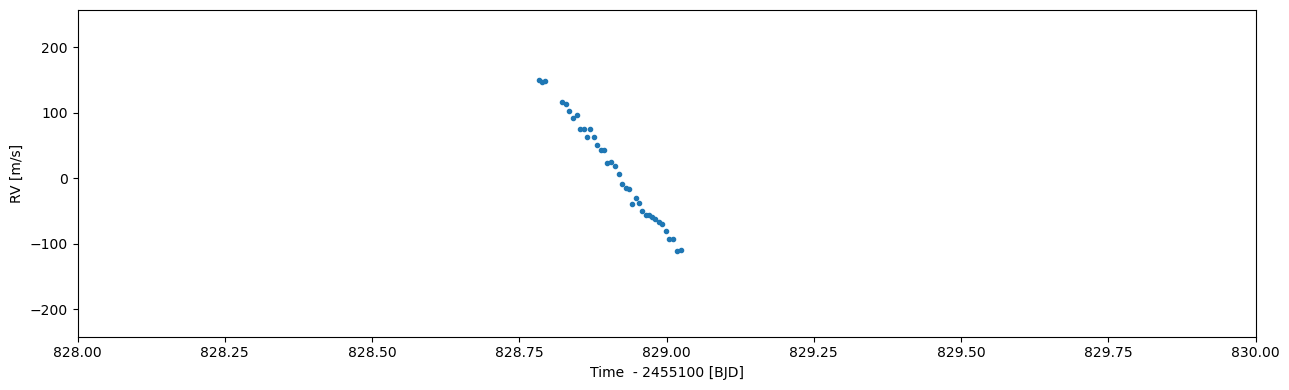

In [17]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] - 2455100, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Time  - 2455100 [BJD]', ylabel='RV [m/s]', xlim=(828, 830))
fig.tight_layout()
plt.show()

## 1.2 Search for a radial velocity signal

First, we use a Lomb-Scargle periodigram to search for a sinusoidial radial velocity signal from the RV measurements. This is simple to do with `astropy.timeseries.LombScargle` class that is initialised with the mid-measurement times and the RV observations.

In [18]:
ls = LombScargle(rv_data['BJD'], rv_data['RVel'])

Next, we use the `LombScargle.autopower` to calculate the periodogram. We restrict the search to $0.5 < P < 5$ days.

In [19]:
frequency, power = ls.autopower(minimum_frequency=1/(5*u.d), maximum_frequency=2/u.d)
period = 1/frequency

In [20]:
best_period = period[argmax(power)]
best_period

<Quantity 1.09144998 d>

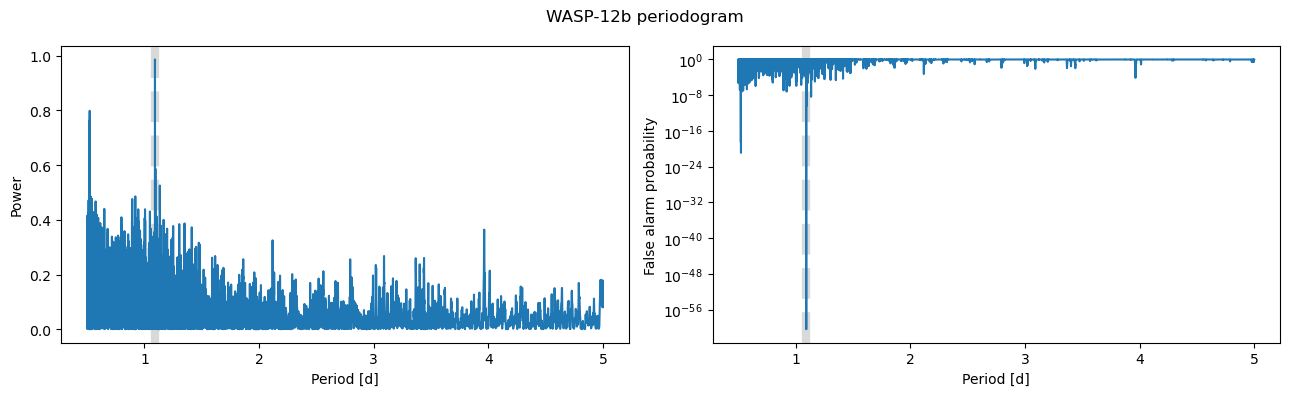

In [21]:
fig, axs = subplots(1, 2, figsize=(13,4))
axs[0].plot(period, power)
axs[1].semilogy(period, ls.false_alarm_probability(power))
[ax.axvline(best_period.value, c='k', ls='--', zorder=-1, lw=6, alpha=0.15) for ax in axs]
setp(axs, xlabel='Period [d]')
setp(axs[0], ylabel='Power')
setp(axs[1], ylabel='False alarm probability')
fig.suptitle('WASP-12b periodogram')
fig.tight_layout()
plt.show()

Let's see what happens when we plot the RV values folded over the best period.

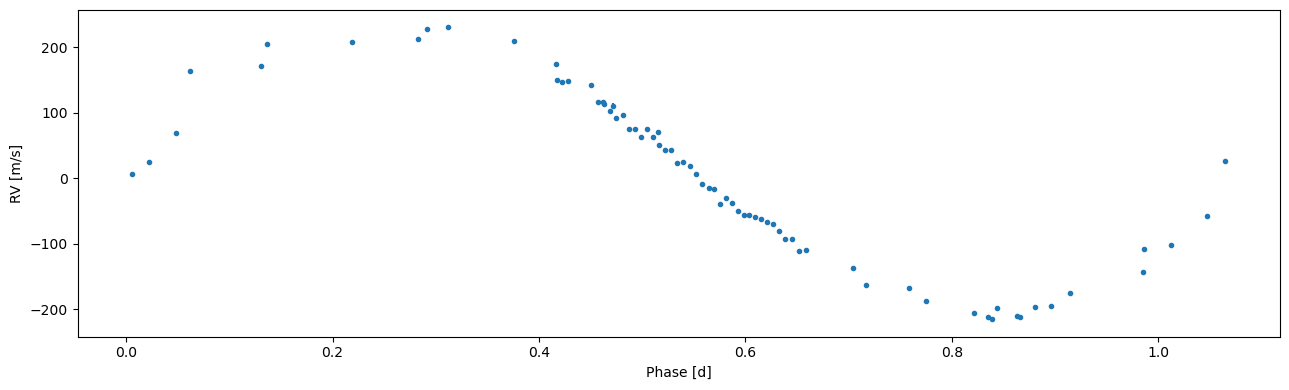

In [22]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] % best_period.value, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Phase [d]', ylabel='RV [m/s]')
fig.tight_layout()
plt.show()

## 1.3 Radial velocity modelling

Now when we know the RV data contains a suspicious signal, we can model it to study what sort of an object is causing it. The two most important parameters we're interested are the orbital period and radial velocity semiamplitude (K). The RV semiamplitude will give us the lower limit of the object's mass ($m\sin i$) which will then tell us whether we're dealing with a planet or something else.

### Initialise the model

In [23]:
lpf = RVLPF('WASP-12b', 1, rv_data['BJD'], rv_data['RVel'], rv_data['e_RVel'])

In [24]:
lpf.ps

[  0 |G| tc_1           N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p_1            N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| secw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   3 |G| sesw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   4 |G| rv_shift_0     N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   5 |G| rv_err_0       U(a = 0.0, b = 1.0)                      [    -inf ..      inf],
   6 |G| rv_k_1         U(a = 0.0, b = 1.0)                      [    0.00 ..      inf],
   7 |G| rv_slope_1     N(μ = 0.0, σ = 1.0)                      [    -inf ..      inf]]

The parameters are

- `tc_1`: transit center [BJD]
- `p_1`: orbital period [d]
- `secw_1`: $\sqrt{e} \cos\omega$, where $e$ is the eccentricity and $\omega$ the argument of periastron
- `sesw_1`: $\sqrt{e} \sin\omega$
- `rv_shift_0`: systemic velocity [m/s]
- `rv_err_0`: additional white noise [m/s]
- `rv_k_1` RV semiamplitude [m/s]
- `rv_slope`: additional linear slope

### Set the parameter priors

Bayesian inference requires a prior probability distribution for each of our model parameters. These "priors" can be based on previous studies, theoretical expectations, or more generally in our beliefs on what values the parameters can take.

In this case we use two priors: a normal prior (NP) and a uniform prior (UP). The normal prior models our prior belief using a normal distribution with a known mean and standard deviation, while the uniform prior says that the paramer can take any value between a minimum and maximum boundary.

In [25]:
lpf.set_prior('tc_1', 'NP', 2458480.65, 0.02) # Normal prior (mean, sigma)
lpf.set_prior('p_1', 'NP', 1.09, 0.1)
lpf.set_prior('rv_shift_0', 'NP', 0.0, 10)
lpf.set_prior('rv_err_0', 'UP', 0.0, 30.0) # Uniform prior (min, max)
lpf.set_prior('rv_k_1', 'UP', 0.0, 300)
lpf.set_prior('rv_slope_1', 'UP', 0.0, 1e-5)

In [26]:
lpf.ps

[  0 |G| tc_1           N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p_1            N(μ = 1.09, σ = 0.1)                     [    0.00 ..      inf],
   2 |G| secw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   3 |G| sesw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   4 |G| rv_shift_0     N(μ = 0.0, σ = 10.0)                     [    -inf ..      inf],
   5 |G| rv_err_0       U(a = 0.0, b = 30.0)                     [    -inf ..      inf],
   6 |G| rv_k_1         U(a = 0.0, b = 300)                      [    0.00 ..      inf],
   7 |G| rv_slope_1     U(a = 0.0, b = 1e-05)                    [    -inf ..      inf]]

### Fit the model to the data

Global optimisation:   0%|          | 0/2000 [00:00<?, ?it/s]

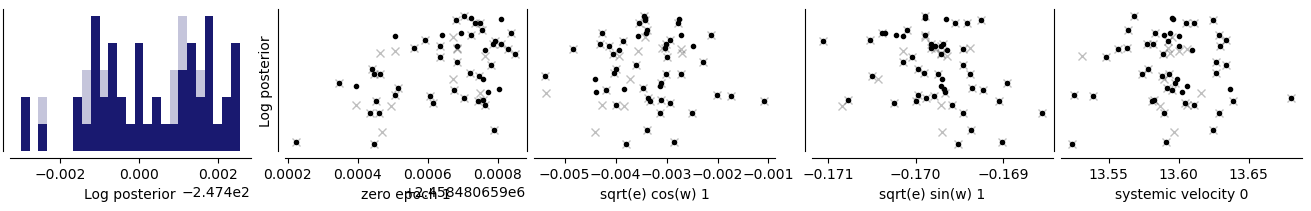

In [31]:
lpf.optimize_global(2000)
plt.show()

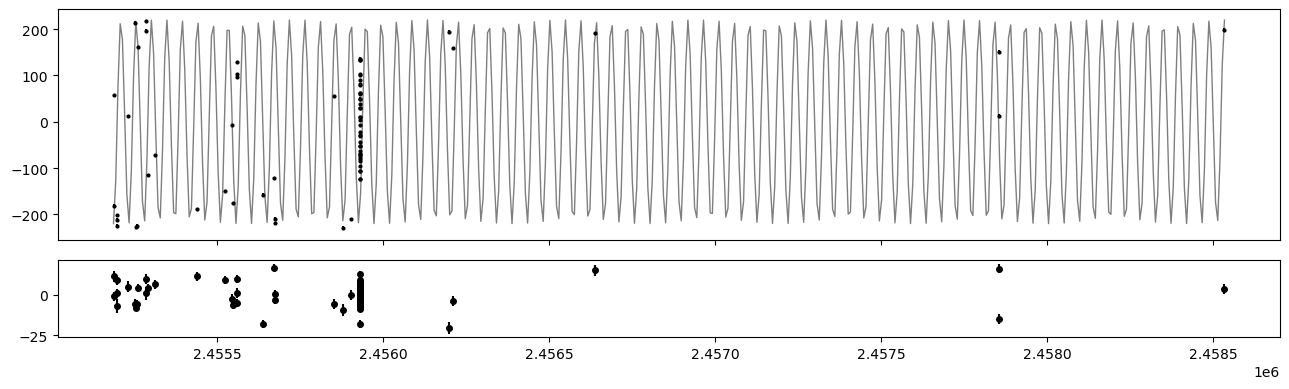

In [28]:
lpf.plot_rv_vs_time();
plt.show()

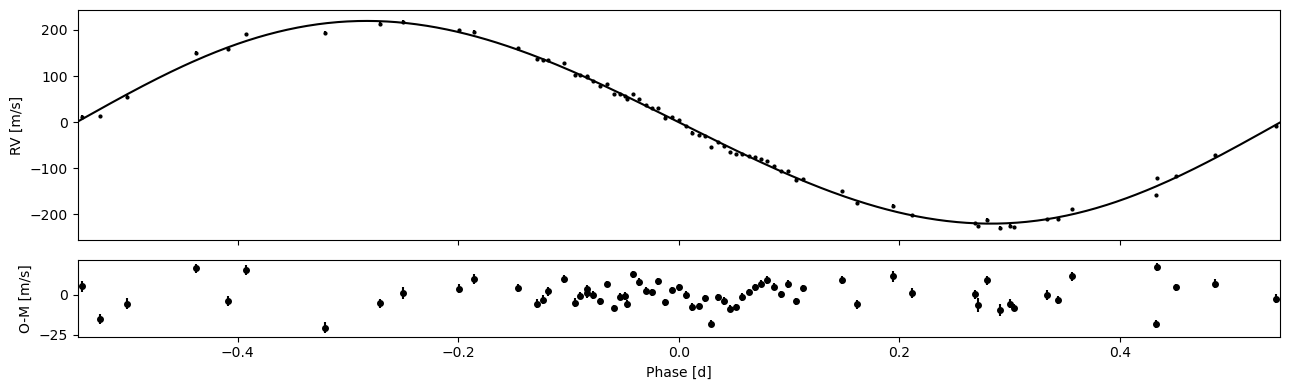

In [32]:
lpf.plot_rv_vs_phase(0);
plt.show()

### Estimate the parameter posterior distributions using MCMC

We estimate the [posterior probability distributions](https://en.wikipedia.org/wiki/Posterior_probability) of our model parameters using [Markov Chain Monte Carlo sampling](https://twiecki.io/blog/2015/11/10/mcmc-sampling). The sampling can be done using the `RVLPF.sample_mcmc` method after a global optimisation run has been finished. The `sample_mcmc` method uses the [*emcee*](https://emcee.readthedocs.io/en/stable) sampler under the hood.

We give `RVLPF.sample_mcmc` the number of MCMC steps to take (`niter`), a thinning factor (`thin`), and a number of repeats (`repeats`). This makes the sampler run first one round of `niter` steps, restarts the sampler from the last step of the previous run, and run again `niter` steps. This is the same as running the sampler for `2 x niter` and keeping only the second half of the steps. The first half is treated as a [warm-up period](https://stats.stackexchange.com/questions/88819/mcmc-methods-burning-samples) for the sampler and discarded. In general, the sampler is run `repeats x niter` steps in total, and only the last `niter` steps are retained.

The thinning factor tells the sampler to store only every $n$th step. In our case, we're storing only every 10th step. Thinning is a way to try to store only statistically independent samples, but is [not really necessary](https://besjournals.onlinelibrary.wiley.com/doi/pdf/10.1111/j.2041-210X.2011.00131.x). However, we'll do it to keep the number of samples low (there's no point in storing a large number of dependent samples either).

In [ ]:
lpf.sample_mcmc(niter=2000, thin=10, repeats=2)
plt.show()

The *emcee* sampler uses an ensemble of MCMC chains to sample the posterior. This means that we have many chains running in parallel. We can plot the traces of each chain to see how the chain population behaves in time.

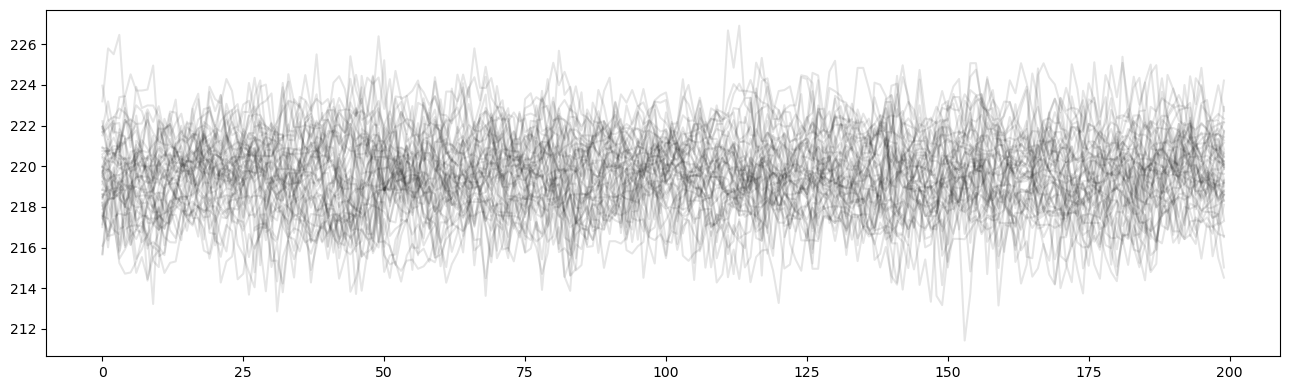

In [36]:
lpf.plot_mcmc_chains(6);
plt.show()

### Plot the model posterior

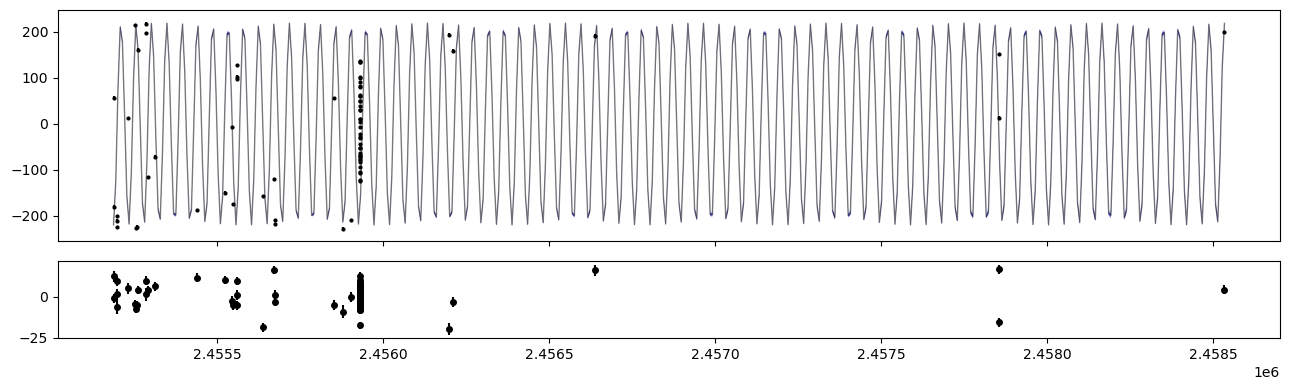

In [37]:
lpf.plot_rv_vs_time('mcmc');
plt.show()

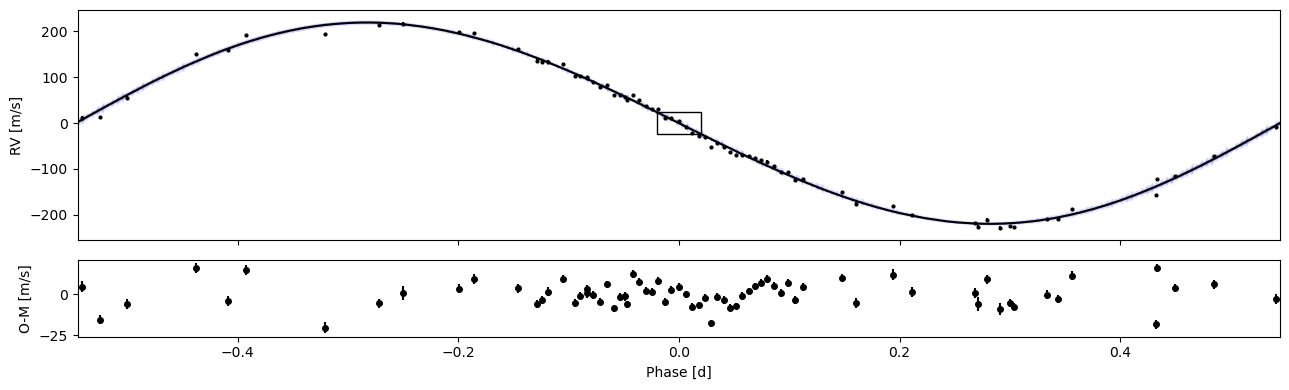

In [38]:
fig = lpf.plot_rv_vs_phase(0, 'mcmc')
fig.axes[0].add_patch(Rectangle((-.02, -25), 0.04, 50, fill=False));
plt.show()

When we zoom a little bit, we can see that we're now actually plotting the probability density of the model. The black line corresponds to the median of the model posterior, and the two shades to the 68% and 95% central posterior limits.

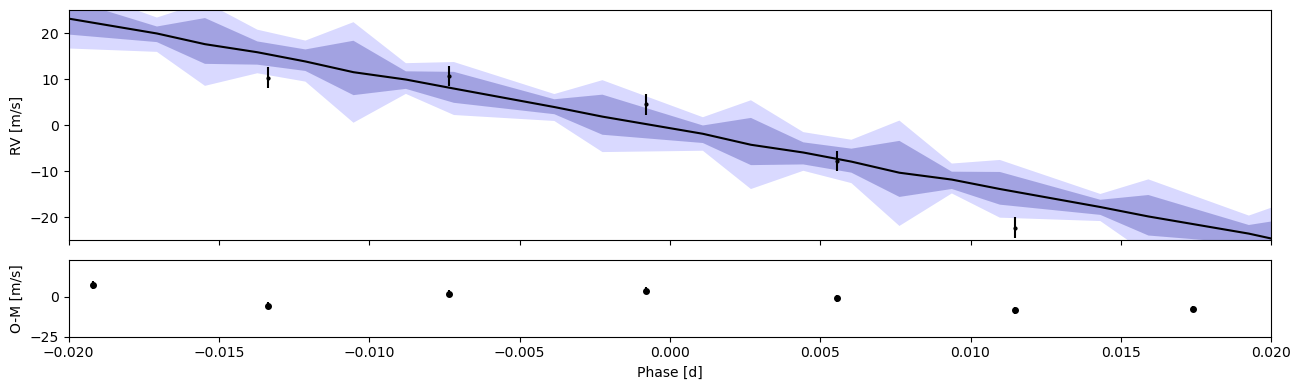

In [39]:
fig = lpf.plot_rv_vs_phase(0, 'mcmc')
setp(fig.axes[0], xlim=(-0.02, 0.02), ylim=(-25,25));
plt.show()

### Plot the parameter posteriors

In [40]:
df = lpf.posterior_samples()
df

,tc_1,p_1,secw_1,sesw_1,rv_shift_0,rv_err_0,rv_k_1,rv_slope_1
0,2.458481e+06,1.091425,-0.003065,-0.165242,13.758667,7.918259,219.975252,0.000009
1,2.458481e+06,1.091425,-0.003855,-0.164294,13.887309,8.022393,219.785452,0.000010
2,2.458481e+06,1.091425,0.002923,-0.165930,13.968105,8.037465,220.320115,0.000009
3,2.458481e+06,1.091426,-0.033729,-0.169048,13.470855,8.971112,221.118991,0.000008
4,2.458481e+06,1.091429,-0.002768,-0.207201,14.050867,9.233832,221.187504,0.000010
...,...,...,...,...,...,...,...,...
9995,2.458481e+06,1.091424,-0.009207,-0.117783,12.569500,7.393002,218.962922,0.000006
9996,2.458481e+06,1.091424,-0.019268,-0.116736,12.486648,7.892347,218.649834,0.000005
9997,2.458481e+06,1.091423,-0.023772,-0.120152,11.768922,7.909185,219.204531,0.000002
9998,2.458481e+06,1.091424,-0.067882,-0.130243,13.316633,7.503961,218.954362,0.000005


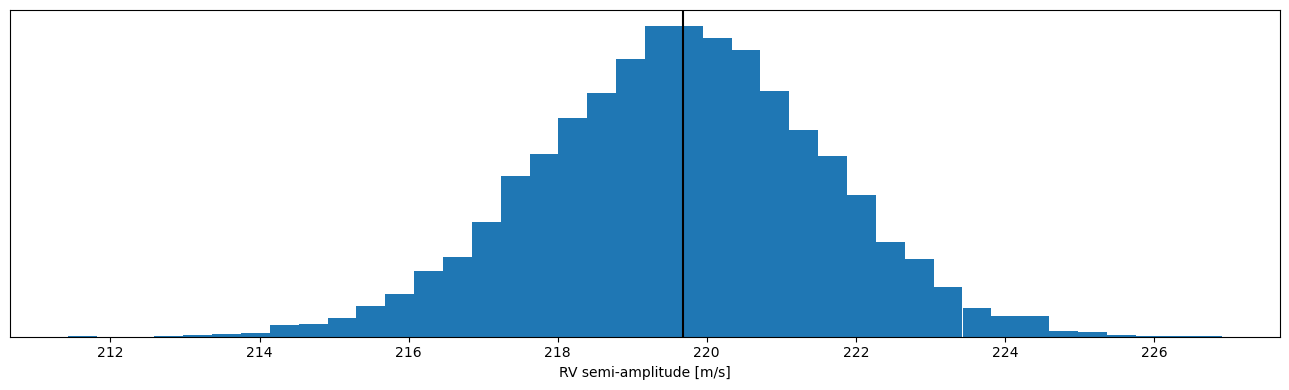

In [41]:
fig, ax = subplots()
ax.hist(df.rv_k_1, bins=40)
ax.axvline(median(df.rv_k_1), c='k')
setp(ax, xlabel='RV semi-amplitude [m/s]', yticks=[])
fig.tight_layout()
plt.show()

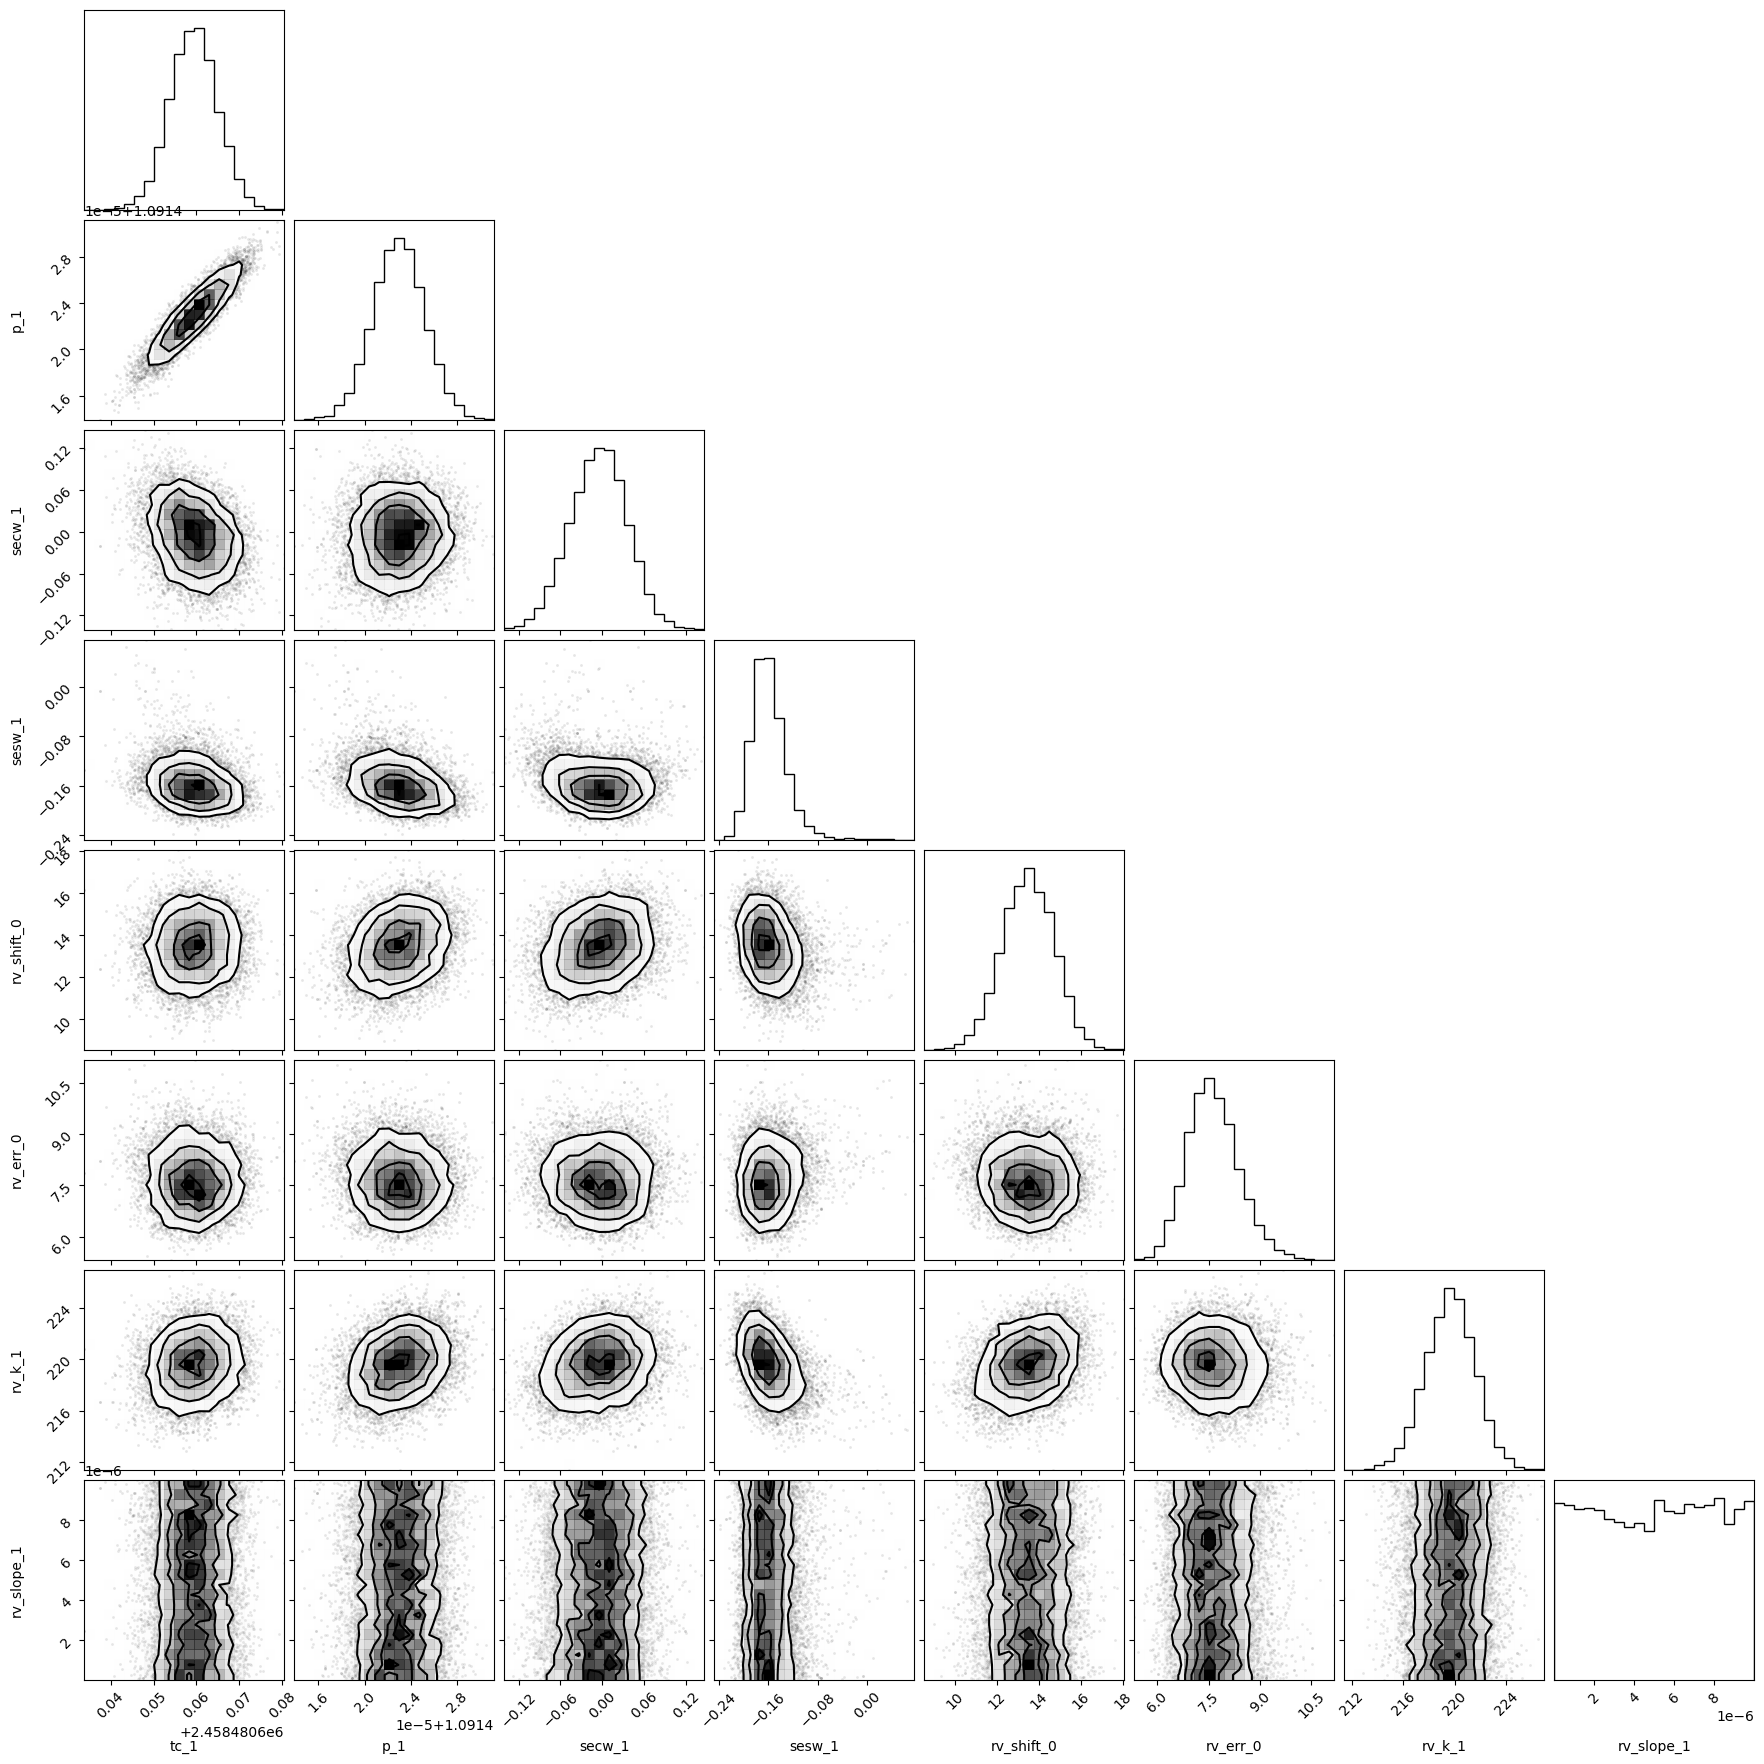

In [43]:
corner(df.values, labels=df.columns);
plt.show()

### <span style="color:darkblue">Questions and exercises</span>

1. We parameterise the model using ($\sqrt{e}\sin\omega$, $\sqrt{e}\cos\omega$) instead of ($e$, $\omega$). This parameterisation is more efficient to sample with an MCMC sampler, but means we need to take some extra steps to get the eccentricity and argument of periastron samples. Write below the equations you need to use to map the sampling parameters to $e$ and $\omega$?

In [45]:
import numpy as np # Asegúrate de importar numpy si no lo has hecho ya

# --- Asumiendo que 'df' es tu DataFrame con las muestras MCMC ---
# df = lpf.posterior_samples() # Esta línea ya estaría ejecutada previamente

# Calcular la excentricidad (e)
# e = (sqrt(e)sin(omega))^2 + (sqrt(e)cos(omega))^2
df['e'] = df['sesw_1']**2 + df['secw_1']**2

# Calcular el argumento del periastro (omega) en radianes
# omega = atan2( sqrt(e)sin(omega), sqrt(e)cos(omega) )
df['omega'] = np.arctan2(df['sesw_1'], df['secw_1'])

# (Opcional) Si quieres omega en grados en lugar de radianes:
# df['omega_deg'] = np.degrees(df['omega'])

# (Opcional) Mostrar las primeras filas con las nuevas columnas para verificar
print("DataFrame con las nuevas columnas 'e' y 'omega':")
print(df[['sesw_1', 'secw_1', 'e', 'omega']].head())



DataFrame con las nuevas columnas 'e' y 'omega':
     sesw_1    secw_1         e     omega
0 -0.165242 -0.003065  0.027314 -1.589343
1 -0.164294 -0.003855  0.027007 -1.594258
2 -0.165930  0.002923  0.027541 -1.553183
3 -0.169048 -0.033729  0.029715 -1.767733
4 -0.207201 -0.002768  0.042940 -1.584156


2. Derive $e$ and $\omega$ from the MCMC samples and plot their histograms.

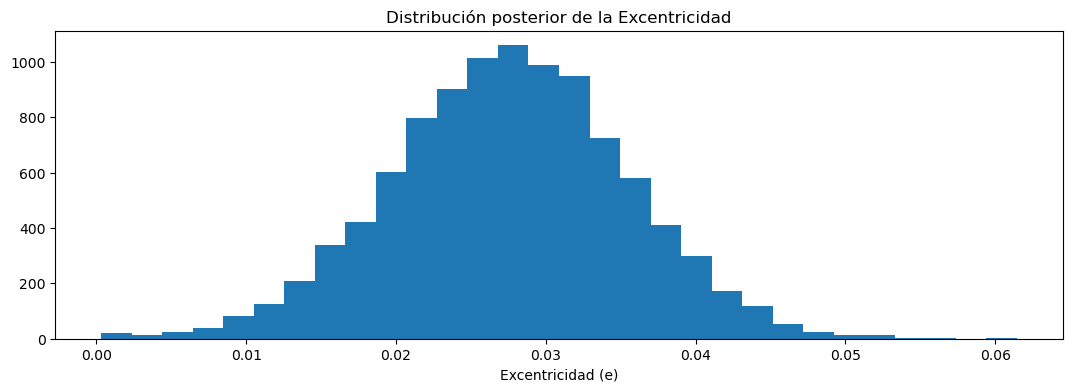

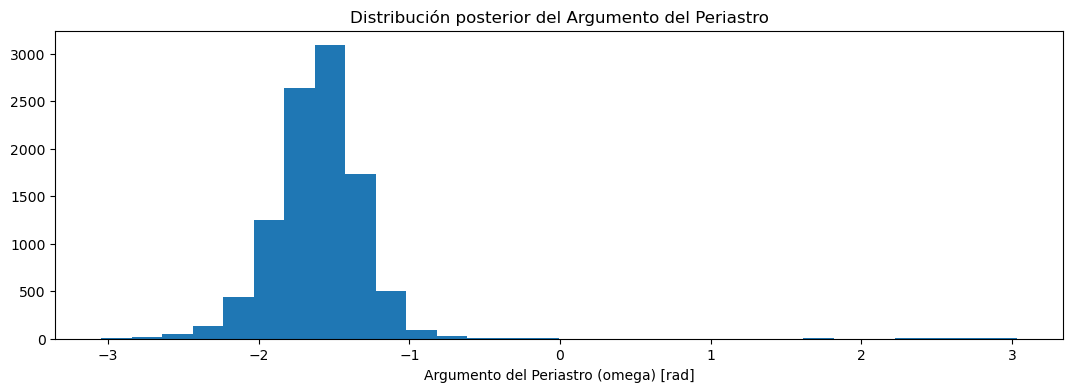

Plotting corner plot for key parameters...


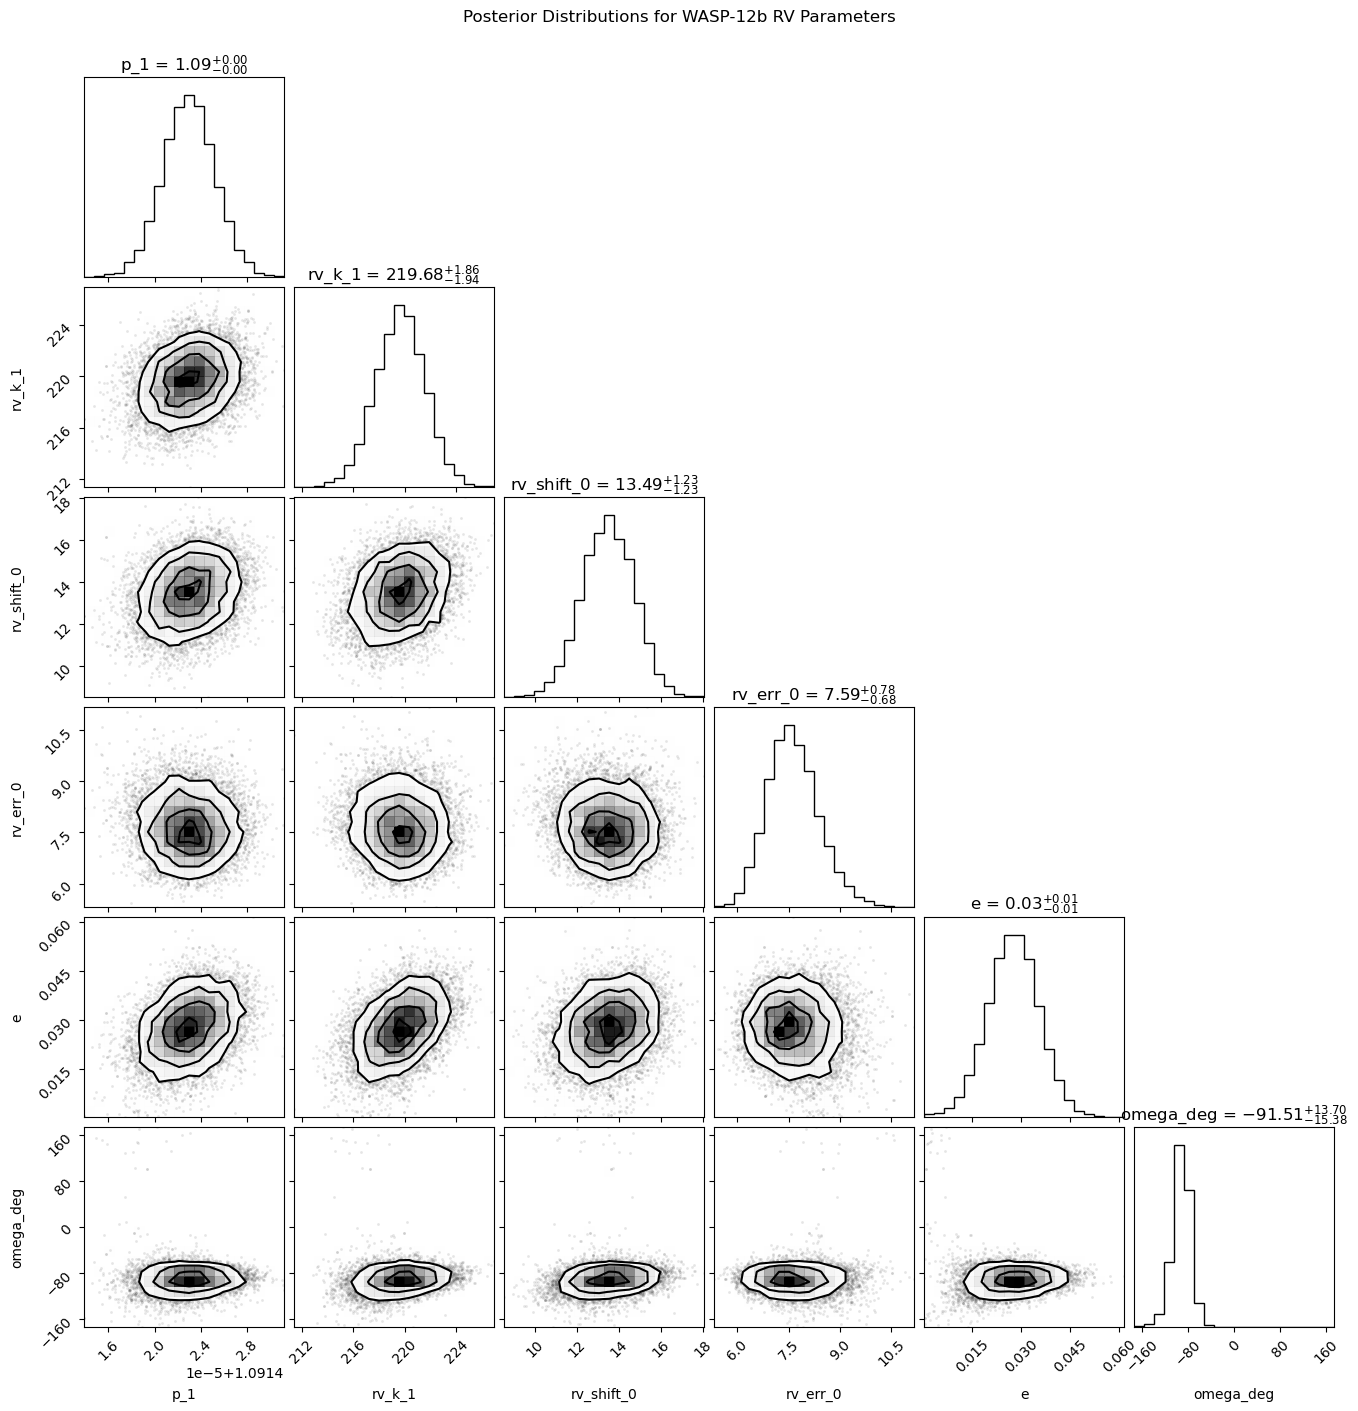

In [74]:
# (Opcional) Ahora podrías usar estas nuevas columnas para hacer histogramas o corner plots

import corner

plt.figure()
plt.hist(df['e'], bins=30)
plt.xlabel('Excentricidad (e)')
plt.title('Distribución posterior de la Excentricidad')
plt.show()

plt.figure()
plt.hist(df['omega'], bins=30) # O df['omega_deg'] si la quieres en grados
plt.xlabel('Argumento del Periastro (omega) [rad]') # O [deg]
plt.title('Distribución posterior del Argumento del Periastro')
plt.show()

print("Plotting corner plot for key parameters...")
# Select key parameters for the corner plot
# Include derived parameters e and omega
corner_params = df[['p_1', 'rv_k_1', 'rv_shift_0', 'rv_err_0', 'e', 'omega_deg']]
# Use the corrected function call: corner.corner()
# show_titles=True displays median and credible interval on 1D histograms
corner.corner(corner_params.values, labels=corner_params.columns, show_titles=True);
plt.suptitle('Posterior Distributions for WASP-12b RV Parameters', y=1.02) # Add a main title
plt.show()

3. What is the posterior density for the minimum mass ($m\sin i$) of WASP-12b? You can derive this from the RV semi-amplitude (K), orbital period (p), and the host star mass.


--- Exercise 3: Posterior density for minimum mass ---
Calculating posterior density for minimum mass...
Plotting posterior histogram for minimum mass...


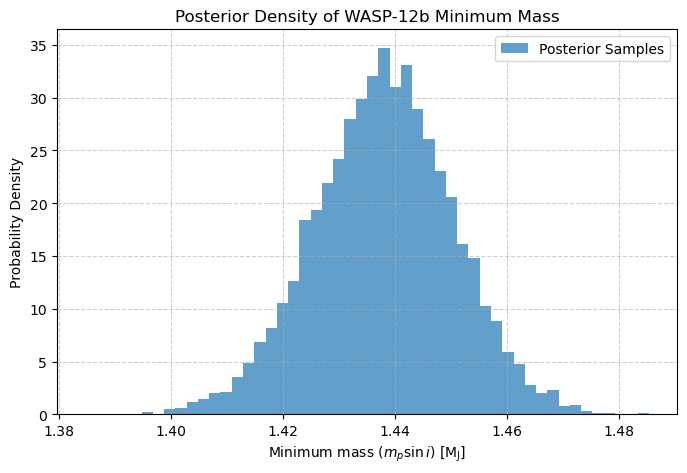

Median minimum mass ($m_p \sin i$): 1.438 $\mathrm{M_{\rm J}}$
68% credible interval: [1.426, 1.450] $\mathrm{M_{\rm J}}$


In [69]:
import numpy as np
import astropy.units as u
import astropy.constants as const
import matplotlib.pyplot as plt
# Assuming 'df' DataFrame with MCMC samples (including 'e') is available from previous steps

# --- Calculate and plot the posterior density for the minimum mass (m_p sin i) ---
print("\n--- Exercise 3: Posterior density for minimum mass ---")
print("Calculating posterior density for minimum mass...")

# Define the host star mass for WASP-12A (from literature, e.g., Yee et al. 2019)
M_star = 1.47* u.M_sun

# Gravitational constant from astropy.constants
G = const.G

# Get the MCMC samples for the relevant parameters from your DataFrame 'df'
# Make sure these columns exist in your 'df'
K_samples = df['rv_k_1'].values * u.m / u.s  # K is in m/s
P_samples = df['p_1'].values * u.d         # Period is in days
e_samples = df['e'].values                 # Eccentricity is dimensionless (calculated earlier)

# Calculate m_p sin i for each sample using the simplified formula (assuming m_p << M_*):
# m_p sin i = K * (P / (2pi G))^(1/3) * M_*^(2/3) * sqrt(1-e^2)
# Using Astropy units handles conversions automatically

m_p_sin_i_samples = K_samples * (P_samples / (2 * np.pi * G))**(1/3) * M_star**(2/3) * np.sqrt(1 - e_samples**2)

# The result is in kg. Convert to a more standard unit for planetary mass, like Jupiter masses (M_jup).
m_p_sin_i_samples_mj = m_p_sin_i_samples.to(u.M_jup)

# --- Plot the posterior density histogram for minimum mass ---
print("Plotting posterior histogram for minimum mass...")
plt.figure(figsize=(8, 5))
plt.hist(m_p_sin_i_samples_mj.value, bins=50, density=True, alpha=0.7, label='Posterior Samples')

plt.xlabel(f'Minimum mass ($m_p \\sin i$) [{u.M_jup:latex_inline}]') # Using LaTeX for M_jup symbol
plt.ylabel('Probability Density')
plt.title('Posterior Density of WASP-12b Minimum Mass')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

# --- Optional: Print summary statistics for minimum mass ---
median_mp_sini = np.median(m_p_sin_i_samples_mj.value)
# Calculate the 68% credible interval (approximately 1-sigma for a symmetric distribution)
lower_bound = np.percentile(m_p_sin_i_samples_mj.value, 16)
upper_bound = np.percentile(m_p_sin_i_samples_mj.value, 84)

print(f"Median minimum mass ($m_p \\sin i$): {median_mp_sini:.3f} {u.M_jup:latex_inline}")
print(f"68% credible interval: [{lower_bound:.3f}, {upper_bound:.3f}] {u.M_jup:latex_inline}")



4. What would be the posterior RV semi-amplitude of an Earth-mass planet orbiting WASP-12 with an orbital period of 365 days?

For a 1 Earth-mass planet orbiting WASP-12A at 365 days (assuming circular, edge-on orbit):
Expected RV semi-amplitude (K): 0.0729 m / s
Expected RV semi-amplitude (K): 7.2895 cm / s

--- Generando gráfica comparativa ---


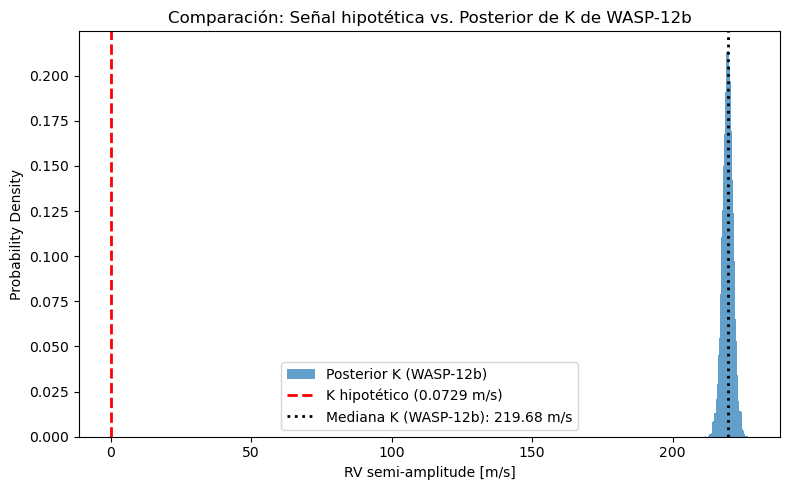

Gráfica comparativa generada.


In [64]:
import numpy as np
import astropy.units as u
import astropy.constants as const

# Define the parameters for the hypothetical planet and star
m_planet = 1 * u.M_earth
period = 365 * u.d # days
m_star = 1.36 * u.M_sun # mass of WASP-12A

# Gravitational constant
G = const.G

# Assume edge-on orbit (i=90 deg) and circular orbit (e=0)
sin_i = 1
sqrt_1_minus_e_sq = 1 # for e=0, sqrt(1-0^2)=1

# Calculate the RV semi-amplitude K using the simplified formula:
# K = (2pi G / P)^(1/3) * m_p / M_*^(2/3)  (with sin_i=1, e=0, m_p << M_*)

# Using Astropy units for calculation:
K_calculated = ((2 * np.pi * G / period)**(1/3)) * (m_planet / (m_star**(2/3)))

# Convert the result to meters per second (m/s)
K_ms = K_calculated.to(u.m / u.s)

print(f"For a 1 Earth-mass planet orbiting WASP-12A at 365 days (assuming circular, edge-on orbit):")
print(f"Expected RV semi-amplitude (K): {K_ms:.4f}")

# It's a very small value, often given in cm/s
K_cms = K_ms.to(u.cm / u.s)
print(f"Expected RV semi-amplitude (K): {K_cms:.4f}")

print("\n--- Generando gráfica comparativa ---")

fig, ax = plt.subplots(figsize=(8, 5))

# Plotea el histograma del posterior de K para WASP-12b (en m/s)
ax.hist(df.rv_k_1, bins=40, density=True, alpha=0.7, label='Posterior K (WASP-12b)')

# Añade una línea vertical en la semi-amplitud calculada para el planeta hipotético (en m/s)
ax.axvline(K_hypothetical_ms.value, color='red', linestyle='dashed', linewidth=2,
           label=f'K hipotético ({K_hypothetical_ms.value:.4f} m/s)')

# Añade una línea vertical en la mediana del posterior de K de WASP-12b
ax.axvline(np.median(df.rv_k_1), color='k', linestyle='dotted', linewidth=2,
           label=f'Mediana K (WASP-12b): {np.median(df.rv_k_1):.2f} m/s')


setp(ax, xlabel='RV semi-amplitude [m/s]', ylabel='Probability Density')
ax.set_title('Comparación: Señal hipotética vs. Posterior de K de WASP-12b')
ax.legend()
fig.tight_layout()
plt.show()

print("Gráfica comparativa generada.")
